In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers, data_generation_gamma, contaminated_normal
from bayesian_dro.Bayesian_DRO_continuous import EPSILON_SET
from mis_dro.models import univariate_GaussianModel
from mis_dro.npl import Npl
from mis_dro.dataset import *
from mis_dro.npl import *
from mis_dro.likelihood import *
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.gaussian_kernel import *
from mis_dro.bayes_conjugates import *

/tmp/dcs-tmp.u1604520/ipykernel_127203/436343965.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [35]:
contamination = 0.1
num_observations = 20
num_posterior_samples = 20
num_likelihood_samples = 20
likelihood = "gaussian"
data = sample_dgp("contaminated_normal", num_observations, contamination)

In [38]:
generator = np.random.default_rng(seed=0)
theta_sample_mmd = sample_npl(
        data,
        "npl_mmd",
        likelihood,
        num_posterior_samples,
        seed=0,
        lengthscale=-1,
        generator=generator,
        )
posterior = "normal_gamma"
theta_prior = default_prior_params(posterior)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
theta_sample_kl = sample_posterior(posterior, theta_posterior, num_likelihood_samples, generator=generator)

In [9]:
def approx_mmd(sample1, sample2):
    m = len(sample1)
    n = len(sample2)
    
    sample1 = sample1.reshape((m,1))
    sample2 = sample2.reshape((n,1))
    
    l = np.sqrt((1/2)*np.median(distance.cdist(sample2, sample2, 'sqeuclidean')))
    
    kyy = k_jax(sample1, sample1, l)
    kxy = k_jax(sample1, sample2, l)
    kxx = k_jax(sample2, sample2, l)

   # first sum
    diag_elements = jnp.diag_indices_from(kyy)
    kyy = kyy.at[diag_elements].set(jnp.repeat(0, m))
    sum1 = jnp.sum(kyy)

    # second sum
    sum2 = jnp.sum(kxy)

    # third sum
    diag_elements = jnp.diag_indices_from(kxx)
    kxx = kxx.at[diag_elements].set(jnp.repeat(0, n))
    sum3 = jnp.sum(kxx)

    return (
        (1 / (m * (m - 1))) * sum1
        - (2 / (n * m)) * sum2
        + (1 / (n * (n - 1))) * sum3
    )

In [10]:
def approx_kl(mu1, std1, mu2, std2):
    return(np.log(std2/std1) +
           std1**2/(2*std2**2) +
           (mu1 - mu2)**2/(2*std2**2) -
           0.5)

In [76]:
# Now I want to visualise the DRO-RoBAS for these samples 
# Ideally I would be able to sample densities P and then see if E[MMD(P, P_theta)] < epsilon 
# I can do this by using my theta samples and approximmating E[MMD()] = 1/B \sum_{b=1}^N MMD(P, P_{theta_b})
# Main question is how to sample P?
# A toy example would be to sample just different means for the Gaussian likelihood
epsilon = 0.8
mean_range = np.linspace(0, 50, num=20)
std_range = np.linspace(0, 20, num=20)
pairs_inside_RoBAS = []
pairs_inside_BAS = []
for mu, std in itertools.product(mean_range, std_range):
    # sample from P
    samples_from_P = generator.normal(
        loc=mu,
        scale=std,
        size=num_likelihood_samples,
    ) 
    
    # for each theta calculate approximate MMD
    mmds = np.zeros(num_posterior_samples)
    for i in range(num_posterior_samples):
        samples_from_Ptheta = generator.normal(
            loc=theta_sample_mmd[i,0],
            scale=theta_sample_mmd[i,1],
            size=num_likelihood_samples,
        )
        
        mmds[i] = approx_mmd(samples_from_P, samples_from_Ptheta)
    exp_mmd = mmds.mean()
    if exp_mmd < epsilon:
        pairs_inside_RoBAS.append((mu,std))
        
    # for each theta calculate approximate KL
    kls = np.zeros(num_posterior_samples)
    for i in range(num_posterior_samples):
        kls[i] = approx_kl(mu, std, theta_sample_kl[i,0], 1/np.sqrt(theta_sample_kl[i,1]))
        
    exp_kl = kls.mean()
    if exp_kl < epsilon:
        pairs_inside_BAS.append((mu,std))
        
         
     
    

(114, 2)


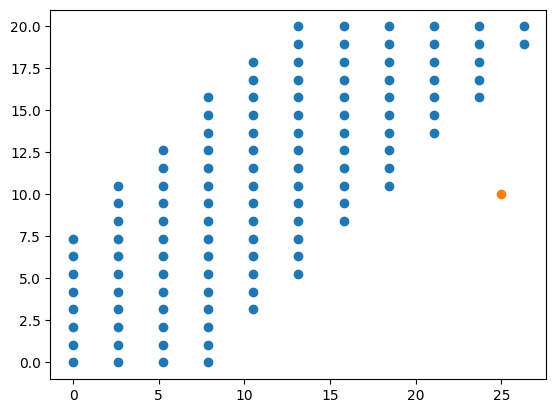

In [77]:
pairs_BAS = np.array(pairs_inside_BAS)
pairs_RoBAS = np.array(pairs_inside_RoBAS)
print(pairs_BAS.shape)
plt.scatter(pairs_BAS[:,0], pairs_BAS[:,1])
plt.scatter(25, 10)
# plt.scatter(pairs_RoBAS[:,0], pairs_RoBAS[:,1])

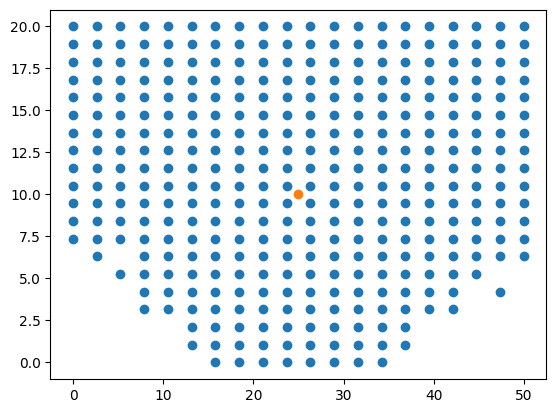

In [78]:
plt.scatter(pairs_RoBAS[:,0], pairs_RoBAS[:,1])
plt.scatter(25, 10)

# Try to replicate example from Gao

In [31]:
def contaminated_normal(num_observations: int, contamination: float, random_state: Optional[np.random.Generator] = None):
    """A contaminated Gaussian data-generating process (DGP)

    Args:
        num_observations: Number of observations from DGP
        contamination: Ratio of contaminated observations (outliers)
        random_state: A numpy random generator, if provided

    Notes:
        Shuffles data to ensure anomalies are not grouped together
    """
    if not random_state:
        random_state = np.random.default_rng()
    cont_size = int(np.floor(contamination * num_observations))
    n_real = num_observations - cont_size
    data = norm.rvs(loc=25, scale=DGP_STD_TRUNCATED_NORMAL, size=n_real, random_state=random_state) 
    outl = norm.rvs(loc=95, scale=DGP_STD_TRUNCATED_NORMAL, size=cont_size, random_state=random_state) 
    data = np.concatenate((data, outl), axis=0)
    random_state.shuffle(data)  # shuffles the data in-place
    return data, outl

In [66]:
contaminations = [0.0, 0.2]
num_observations = 500
num_posterior_samples = 100
num_likelihood_samples = 100
likelihood = "gaussian"
generator = np.random.default_rng(seed=0)
data_true = sample_dgp("contaminated_normal", num_observations, contaminations[0])
data_observed, outl = contaminated_normal(num_observations, contaminations[1])
data_pathological = norm.rvs(
            loc=40,
            scale=DGP_STD_TRUNCATED_NORMAL,
            size=num_observations,
            random_state=generator,
        )
datasets = [data_true, data_observed, data_pathological]

In [67]:
generator = np.random.default_rng(seed=0)
theta_sample_mmd = sample_npl(
data_observed,
"npl_mmd",
likelihood,
num_posterior_samples,
seed=0,
lengthscale=-1,
generator=generator,
)
posterior = "normal_gamma"
theta_prior = default_prior_params(posterior)
theta_posterior = get_posterior_params(posterior, data_observed, theta_prior)
theta_sample_kl = sample_posterior(posterior, theta_posterior, num_posterior_samples, generator=generator) 

/tmp/dcs-tmp.u1604520/ipykernel_127203/3306471459.py:24: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.histplot(data=data_df, x='Value', hue='Dataset and mean', ax=ax, bins=30, palette=pal, legend=True)


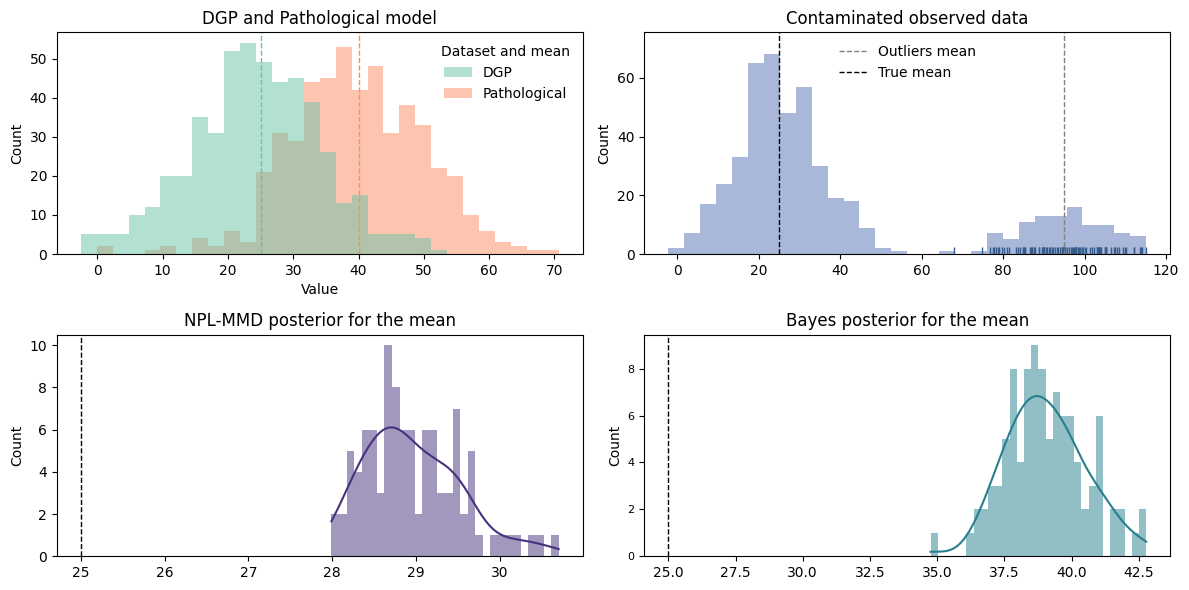

In [68]:
import seaborn as sns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,6)) #, , sharey=True) sharex=True
pal = sns.color_palette("Set2")
pal2 = sns.color_palette("viridis")
plt.rcParams['patch.linewidth'] = 0

data_df = pd.DataFrame({
    'Value': np.concatenate([datasets[0], datasets[2]]),
    'Dataset and mean': ['DGP'] * len(datasets[0]) + ['Pathological'] * len(datasets[2])  # Create a label for each dataset
})

means = [25, 25, 40]
titles = ["DGP and Pathological model", "Contaminated observed data", "Pathological case"]

ax = axes[0][1]
sns.histplot(datasets[1], ax=ax, bins=30, color=pal[2])  #kde=True
sns.rugplot(outl, color=pal2[1], ax=ax, height=0.03)
ax.axvline(x=95, color='gray', linestyle='--', lw=1, label='Outliers mean')
ax.axvline(x=means[0], color='black', linestyle='--', lw=1, label='True mean')
ax.set_title(titles[1])
ax.legend()

ax = axes[0][0]
sns.histplot(data=data_df, x='Value', hue='Dataset and mean', ax=ax, bins=30, palette=pal, legend=True)
# sns.histplot(datasets[2], ax=ax, bins=30, color=pal[2], edgecolor=pal[i], kde=True, label="Pathological", legend="False")
ax.axvline(x=means[2], color=pal[1], linestyle='--', lw=1, label='Pathological mean')
ax.axvline(x=means[0], color=pal[0], linestyle='--', lw=1, label='True mean')
ax.set_title(titles[0])

ax = axes[1][0]
sns.histplot(theta_sample_mmd[:,0], ax=ax, fill=True, color=pal2[0], legend=False, kde=True, bins=30)
ax.axvline(x=means[0], color='black', linestyle='--', lw=1)
ax.set_title('NPL-MMD posterior for the mean')

ax = axes[1][1]
sns.histplot(theta_sample_kl[:,0], ax=ax, fill=True, color=pal2[2], kde=True, bins=30)
ax.axvline(x=means[0], color='black', linestyle='--', lw=1, label='True mean')
ax.set_title('Bayes posterior for the mean')



plt.tick_params(axis='y', labelsize=8) 
plt.tight_layout()
plt.show()

    


In [69]:
# Compute expected KL and expected MMD distance from pathological case and MMD


samples_from_P = generator.normal(
        loc=40,
        scale=DGP_STD_TRUNCATED_NORMAL,
        size=1000,
    )
 
# MMD
# for each theta calculate approximate MMD 
# to P
mmds_P = np.zeros(num_posterior_samples)
mmds_DGP = np.zeros(num_posterior_samples)
for i in range(num_posterior_samples):
    samples_from_Ptheta = generator.normal(
        loc=theta_sample_mmd[i,0],
        scale=theta_sample_mmd[i,1],
        size=num_likelihood_samples,
    )
        
    mmds_P[i] = approx_mmd(samples_from_P, samples_from_Ptheta)
    mmds_DGP[i] = approx_mmd(data_true, samples_from_Ptheta)
exp_mmd_P = mmds_P.mean()
exp_mmd_DGP = mmds_DGP.mean()
    

# KL
# for each theta calculate approximate KL
# to P
kls_P = np.zeros(num_posterior_samples)
kls_DGP = np.zeros(num_posterior_samples)
for i in range(num_posterior_samples):  
    kls_P[i] = approx_kl(40, DGP_STD_TRUNCATED_NORMAL, theta_sample_kl[i,0], 1/np.sqrt(theta_sample_kl[i,1]))
    kls_DGP[i] = approx_kl(25, DGP_STD_TRUNCATED_NORMAL, theta_sample_kl[i,0],  1/np.sqrt(theta_sample_kl[i,1]))
exp_kl_P = kls_P.mean()
exp_kl_DGP = kls_DGP.mean()
    

print(exp_mmd_P, exp_mmd_DGP, "MMD")
print(exp_kl_P, exp_kl_DGP, "KL")



0.16178516084492764 0.05261103690856099 MMD
0.6519281968253108 0.7620806729365295 KL


In [63]:
theta_sample_mmd.shape

(100, 2)

In [81]:
pip install seaborn

/usr/lib64/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 5.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
